GLOBAL IMPORTS AND CONFIGURATION

In [1]:
import sys
from random import random

import re
import unicodedata
from collections import Counter

sys.path.insert(0, '..')

import pandas as pd
import numpy as np
import matplotlib.ticker as mtick
import matplotlib.pyplot as plt
import seaborn as sns

from app.utils.preprocessor import clean_html, build_chunk_document
from app.utils.chunker import JobDescriptionChunker

sns.set_theme(style='whitegrid', context='notebook')
pd.set_option('display.max_columns', 120)
pd.set_option('display.max_rows', 20)

LOADING THE DATASET

In [2]:
df = pd.read_csv('../data/LFJobs.csv', dtype=str).fillna('')
print(f"Dataset shape: {df.shape}")
print(f"Dataset columns: {df.columns.tolist()}")
df.head(3)

Dataset shape: (1000, 9)
Dataset columns: ['ID', 'Job Category', 'Job Title', 'Company Name', 'Publication Date', 'Job Location', 'Job Level', 'Tags', 'Job Description']


,ID,Job Category,Job Title,Company Name,Publication Date,Job Location,Job Level,Tags,Job Description
0,LF0001,Data and Analytics,"DIR, Equities Quant",Merrill,2025-07-28T23:00:54Z,"New York, NY",Mid Level,,<p><b>Job Description:</b><br><br>At Bank of A...
1,LF0002,Data and Analytics,Lead Administrator - L1,Wipro,2025-06-15T23:43:28Z,"Hyderabad, India",Senior Level,,"<p>Wipro Limited (NYSE: WIT, BSE: 507685, NSE:..."
2,LF0003,Data and Analytics,Principal DEX Solutions Architect,Eaton,2025-07-30T11:38:27Z,"Chicago, IL",Senior Level,,<p>Eaton's Digital Employee Experience (DEX) t...


PRELIMINARY EXPLORATION

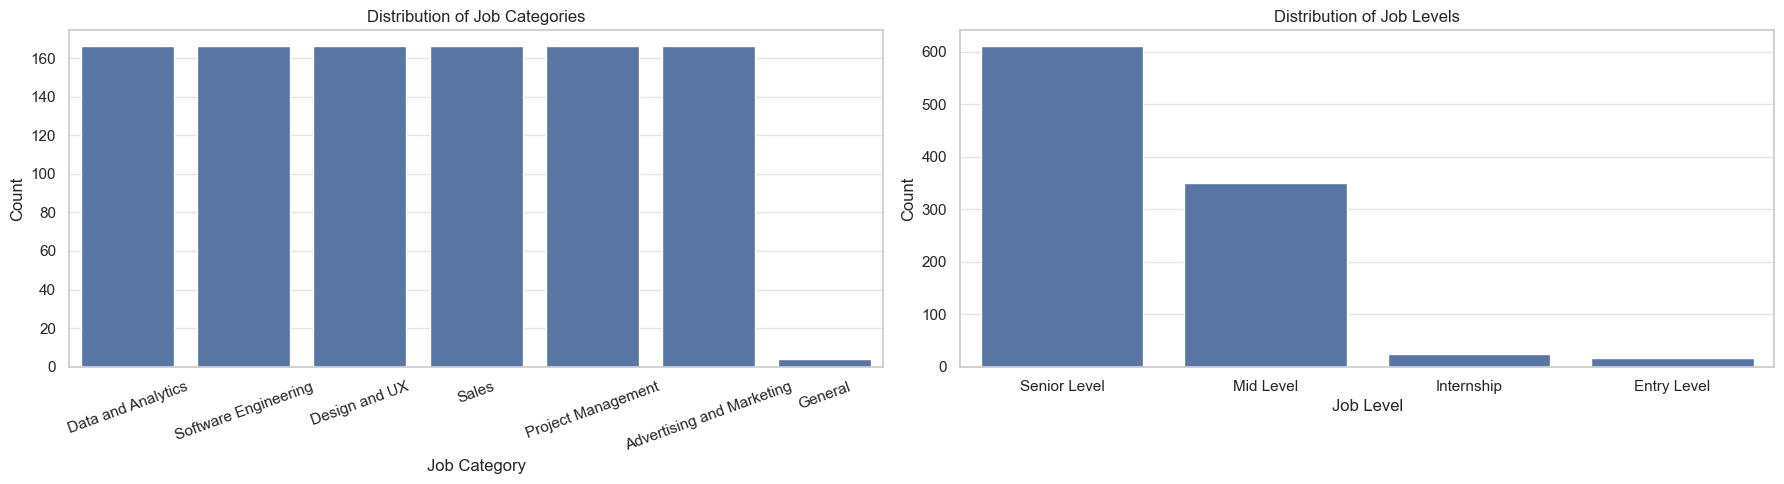

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(18, 5))

#Job Categories
sns.countplot(x='Job Category', data=df, order=df['Job Category'].value_counts().index, ax=axes[0])
axes[0].set_title('Distribution of Job Categories')
axes[0].set_xlabel('Job Category')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', labelrotation=20)

#Job Levels
sns.countplot(x='Job Level', data=df, order=df['Job Level'].value_counts().index, ax=axes[1])
axes[1].set_title('Distribution of Job Levels')
axes[1].set_xlabel('Job Level')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.savefig('../docs/dataset_dist.png')
plt.show()

*Seems to be evenly distributed across categories except for a sharp decline of the general category. The job level distribution seems to be heavily skewed towards the senior position with very little counts for the entry level positions.*

DESCRIPTION LENGTH ANALYSIS

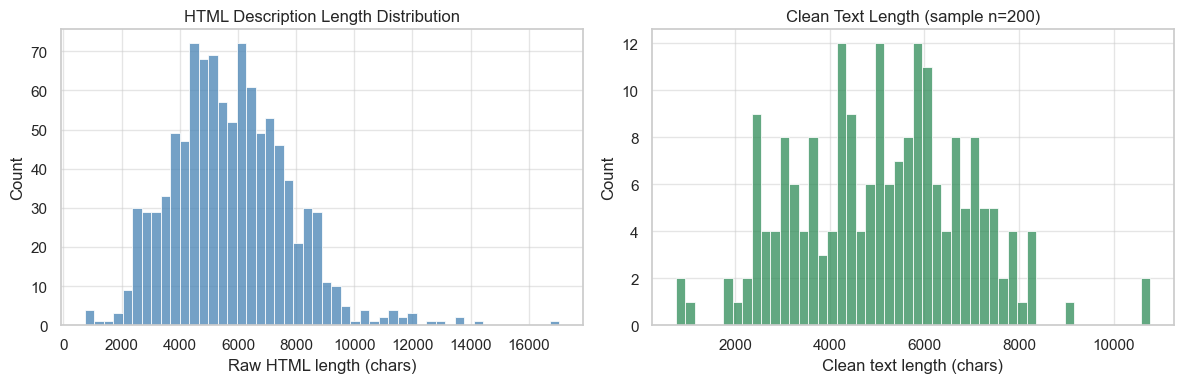


HTML length  — mean: 5755, median: 5616
Clean length — mean: 5118, median: 5116
Compression ratio: 92.89%


In [4]:
df['html_len'] = df['Job Description'].str.len()

sample = df.sample(min(200, len(df)), random_state=42)
sample['clean_len'] = sample['Job Description'].apply(lambda x: len(clean_html(x)))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(data=df, x='html_len', bins=50, ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_xlabel('Raw HTML length (chars)')
axes[0].set_ylabel('Count')
axes[0].set_title('HTML Description Length Distribution')

sns.histplot(data=sample, x='clean_len', bins=50, ax=axes[1], color='seagreen', edgecolor='white')
axes[1].set_xlabel('Clean text length (chars)')
axes[1].set_ylabel('Count')
axes[1].set_title('Clean Text Length (sample n=200)')

plt.tight_layout()
plt.savefig('../docs/description_lenth.png')
plt.show()

print(f"\nHTML length  — mean: {df['html_len'].mean():.0f}, median: {df['html_len'].median():.0f}")
print(f"Clean length — mean: {sample['clean_len'].mean():.0f}, median: {sample['clean_len'].median():.0f}")
print(f"Compression ratio: {sample['clean_len'].mean() / sample['html_len'].mean():.2%}")

CHUNKING STATISTICS AND ANALYSIS

2026-05-19 12:41:10 [info     ] chunker_initialised            chunk_overlap=64 chunk_size=512
2026-05-19 12:41:10 [debug    ] document_chunked               job_id=LF0001 num_chunks=13
2026-05-19 12:41:10 [debug    ] document_chunked               job_id=LF0002 num_chunks=18
2026-05-19 12:41:10 [debug    ] document_chunked               job_id=LF0003 num_chunks=18
2026-05-19 12:41:10 [debug    ] document_chunked               job_id=LF0004 num_chunks=12
2026-05-19 12:41:10 [debug    ] document_chunked               job_id=LF0005 num_chunks=16
2026-05-19 12:41:10 [debug    ] document_chunked               job_id=LF0006 num_chunks=11
2026-05-19 12:41:10 [debug    ] document_chunked               job_id=LF0007 num_chunks=24
2026-05-19 12:41:10 [debug    ] document_chunked               job_id=LF0008 num_chunks=15
2026-05-19 12:41:10 [debug    ] document_chunked               job_id=LF0009 num_chunks=18
2026-05-19 12:41:10 [debug    ] document_chunked               job_id=LF0010 num_chunk

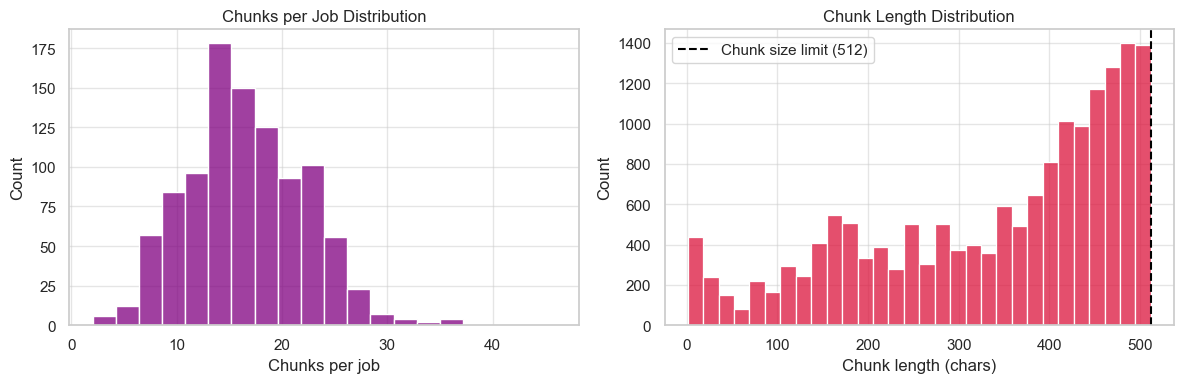

In [5]:
chunker = JobDescriptionChunker()

chunk_counts = []
chunk_lengths = []

for _, row in df.iterrows():
    doc_text = build_chunk_document(dict(row))
    metadata = {
        'job_id': row.get('ID', ''),
        'job_title': row.get('Job Title', ''),
        'company_name': row.get('Company Name', ''),
        'job_category': row.get('Job Category', ''),
        'job_level': row.get('Job Level', ''),
        'job_location': row.get('Job Location', ''),
        'publication_date': row.get('Publication Date', ''),
        'tags': row.get('Tags', ''),
    }
    chunks = chunker.chunk_document(doc_text, metadata)
    chunk_counts.append(len(chunks))
    chunk_lengths.extend([len(c['text']) for c in chunks])

print(f'Total chunks generated : {sum(chunk_counts):,}')
print(f'Avg chunks per job     : {np.mean(chunk_counts):.1f} (σ={np.std(chunk_counts):.1f})')
print(f'Max chunks for one job : {max(chunk_counts)}')
print(f'Min chunks for one job : {min(chunk_counts)}')
print(f'Avg chunk length (chars): {np.mean(chunk_lengths):.0f}')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(x=chunk_counts, bins=20, ax=axes[0], color='purple', edgecolor='white')
axes[0].set_xlabel('Chunks per job')
axes[0].set_title('Chunks per Job Distribution')

sns.histplot(x=chunk_lengths, bins=30, ax=axes[1], color='crimson', edgecolor='white')
axes[1].axvline(512, color='black', linestyle='--', label='Chunk size limit (512)')
axes[1].set_xlabel('Chunk length (chars)')
axes[1].set_title('Chunk Length Distribution')
axes[1].legend()

plt.tight_layout()
plt.savefig('../docs/chunking_stats.png')
plt.show()

TOP COMPANIES BY JOB

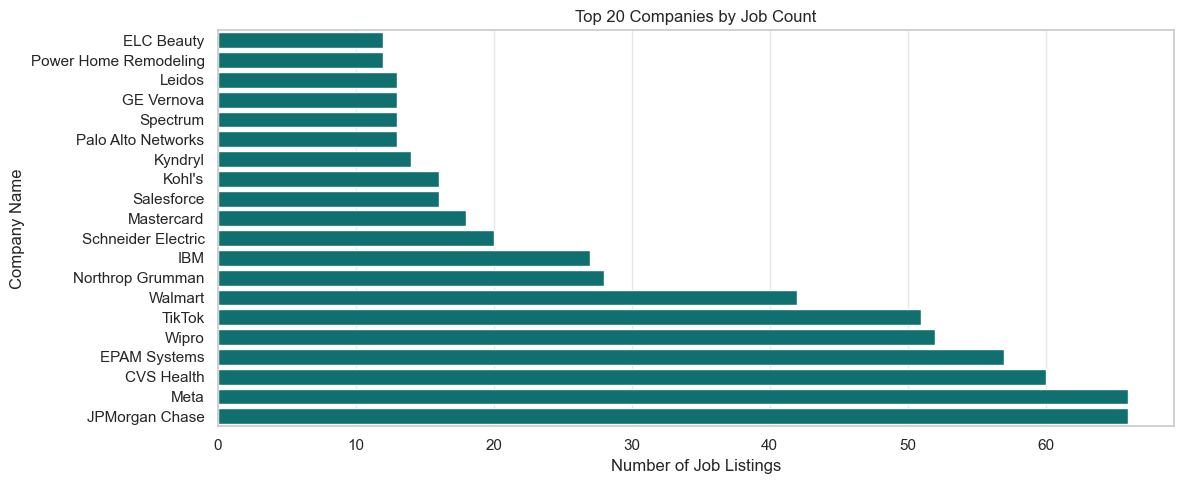

Company Name
Meta                     66
JPMorgan Chase           66
CVS Health               60
EPAM Systems             57
Wipro                    52
TikTok                   51
Walmart                  42
Northrop Grumman         28
IBM                      27
Schneider Electric       20
Mastercard               18
Kohl's                   16
Salesforce               16
Kyndryl                  14
GE Vernova               13
Leidos                   13
Spectrum                 13
Palo Alto Networks       13
ELC Beauty               12
Power Home Remodeling    12


In [6]:
top_companies = df['Company Name'].value_counts().head(20)
top_companies_sorted = top_companies.sort_values()

plt.figure(figsize=(12, 5))
sns.barplot(x=top_companies_sorted.values, y=top_companies_sorted.index, color='teal')
plt.xlabel('Number of Job Listings')
plt.title('Top 20 Companies by Job Count')

plt.tight_layout()
plt.savefig('../docs/top_companies.png')
plt.show()

print(top_companies.to_string())

TAG ANALYSIS

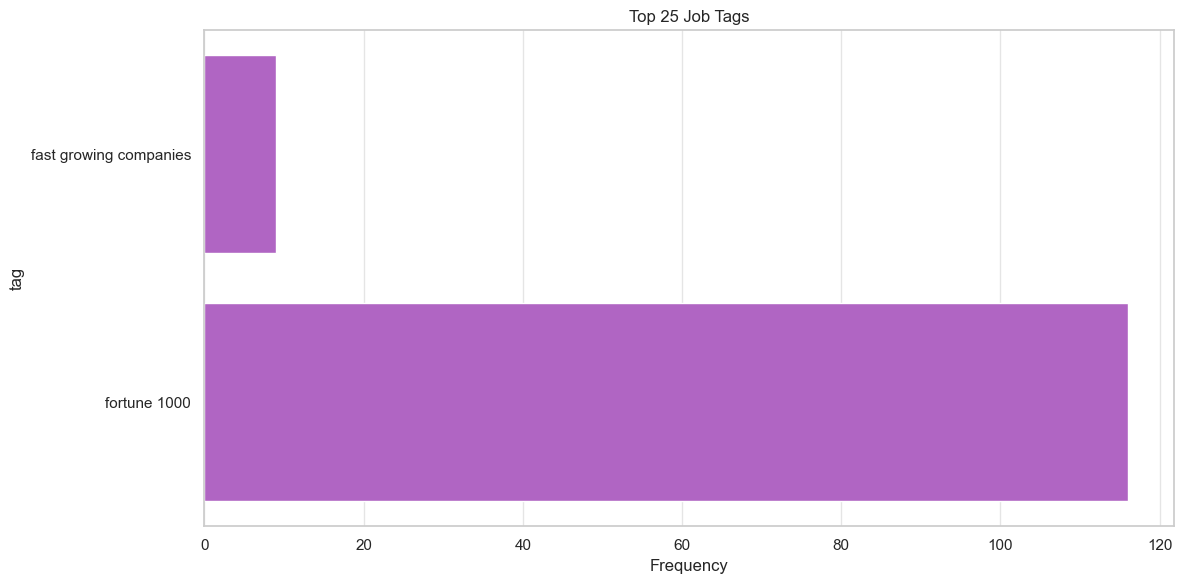

Total unique tags: 2
Total tag occurrences: 125


In [7]:
all_tags = []
for tags_str in df['Tags']:
    if tags_str.strip():
        for tag in tags_str.split(','):
            cleaned = tag.strip().lower()
            if cleaned:
                all_tags.append(cleaned)

tag_counts = Counter(all_tags)
top_tags = tag_counts.most_common(25)

tags_df = pd.DataFrame(top_tags, columns=['tag', 'count'])
tags_df_sorted = tags_df.sort_values('count')

plt.figure(figsize=(12, 6))
sns.barplot(x='count', y='tag', data=tags_df_sorted, color='mediumorchid')
plt.xlabel('Frequency')
plt.title('Top 25 Job Tags')
plt.tight_layout()
plt.show()

print(f'Total unique tags: {len(tag_counts)}')
print(f'Total tag occurrences: {sum(tag_counts.values())}')